# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<h2>Global Tech Workforce Intelligence & Compensation Analysis</h2>
The modern technology job market is undergoing a rapid transformation driven by the expansion of Artificial Intelligence (AI), Machine Learning (ML), and remote work models. Understanding global compensation benchmarks, regional hiring demand, and critical skill combinations is essential for both employers and tech professionals.  This project utilizes the Open Global Workforce Intelligence Platform (OGWIP) dataset—a comprehensive repository combining real-world job posting data from YCombinator's HackerNews, federal public sector feeds (USAJOBS), and LLM-extracted metadata. This project establishes an empirical baseline of global hiring trends through exploratory data analysis and prepares structured feature representations to feed downstream predictive models.

# OJBECTIEVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Primary Objectives (EDA Phase)
<ul>
<li>Compensation & Geographical Mapping: Uncover compensation distributions across key geographic hubs (North America, Europe, APAC) and analyze pay parity across remote, hybrid, and on-site roles.</li>
<li>Tech Stack & Skill Co-occurrence: Quantify market demand for key technical skills (Python, SQL, PyTorch, LLMs, Cloud platforms) and identify high-value skill clusters. </li>
<li> Seniority & Role Benchmark: Evaluate how salary scales across seniority levels (Junior to Staff/Principal) and role classifications (e.g., Data Scientist, DevOps Architect, Product Manager). </li>
</ul>
<li> Future Objectives (ML Phase)Salary Prediction Model (Regression):
<ul> 
<li>Predict continuous compensation figures (salary_in_usd) based on regional features, role category, experience level, and tech stack.</li>
<li>Skill Demand & Seniority Classification (Classification): Build multiclass classifiers to predict job seniority or role tiers using tech stack features and text representation.
<li>Skill Association Mining (NLP / Clustering): Extract latent skill patterns and grouping using topic modeling or unsupervised clustering to track emerging AI tech stacks.
</ul>
</ul>


</div>

<div>

# 1. Getting Ready with Dataset

In [70]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns


In [71]:
data = pl.read_csv('/home/kartika/Datasets/global_tech_market_2026.csv')
data = data.to_pandas()
data.head()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
0,OGWIP_100001,Product Manager,European Space Agency,"Austin, TX, USA",81405,113143,"Python, SQL, TensorFlow, PyTorch",HackerNews,"We are European Space Agency, looking for a Pr...",2026-08-04 05:00:00
1,OGWIP_100003,NLP Engineer,Federal Bureau of Investigation,Remote - US Only,74906,118550,"Java, Spring Boot, Kafka, PostgreSQL",LinkedIn_Proxy,"We are Federal Bureau of Investigation, lookin...",2026-08-01 13:00:00
2,OGWIP_100004,Lead Data Scientist,AI Solutions LLC,Remote - Global,144270,215864,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are AI Solutions LLC, looking for a Lead Da...",2026-08-04 21:00:00
3,OGWIP_100005,Full Stack Developer,NASA,"Seattle, WA, USA",109716,165103,"Python, Airflow, Snowflake, dbt",HackerNews,"We are NASA, looking for a Full Stack Develope...",2026-08-02 22:00:00
4,OGWIP_100006,Technical Program Manager,Quantum Data,"Amsterdam, Netherlands",73276,111586,"JavaScript, React, Node.js, MongoDB",HackerNews,"We are Quantum Data, looking for a Technical P...",2026-08-02 05:00:00


In [72]:
data.tail()

,job_id,job_title,company_name,location,salary_min_usd,salary_max_usd,tech_stack,source,description,date_posted
11998,OGWIP_114995,Analytics Engineer,AI Solutions LLC,"Berlin, Germany",66203,89794,"Ruby on Rails, Redis, Heroku",HackerNews,"We are AI Solutions LLC, looking for a Analyti...",2026-08-01 07:00:00
11999,OGWIP_114996,Cybersecurity Analyst,GlobalSystems Inc,"Seattle, WA, USA",122405,148161,"Rust, WebAssembly, System Architecture",Glassdoor_Scrape,"We are GlobalSystems Inc, looking for a Cybers...",2026-08-03 16:00:00
12000,OGWIP_114997,Senior Data Scientist,TechNova,"Amsterdam, Netherlands",124022,192159,"Go, Kubernetes, Docker, GCP",Glassdoor_Scrape,"We are TechNova, looking for a Senior Data Sci...",2026-08-01 11:00:00
12001,OGWIP_114998,Analytics Engineer,Globex,"New York, NY, USA",106839,179666,"C++, CUDA, Computer Vision",HackerNews,"We are Globex, looking for a Analytics Enginee...",2026-08-02 14:00:00
12002,OGWIP_114999,Technical Program Manager,FinTech Innovations,"Austin, TX, USA",84827,119438,"Go, Kubernetes, Docker, GCP",LinkedIn_Proxy,"We are FinTech Innovations, looking for a Tech...",2026-08-01 10:00:00


In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12003 entries, 0 to 12002
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_id          12003 non-null  object
 1   job_title       12003 non-null  object
 2   company_name    12003 non-null  object
 3   location        12003 non-null  object
 4   salary_min_usd  12003 non-null  int64 
 5   salary_max_usd  12003 non-null  int64 
 6   tech_stack      12003 non-null  object
 7   source          12003 non-null  object
 8   description     12003 non-null  object
 9   date_posted     12003 non-null  object
dtypes: int64(2), object(8)
memory usage: 937.9+ KB


In [74]:
print(f"Size: {data.size}\n Shape: {data.shape}")

Size: 120030
 Shape: (12003, 10)


<div>

# 2. Cleaning and Wraggling

In [75]:
data.isnull().sum()

job_id            0
job_title         0
company_name      0
location          0
salary_min_usd    0
salary_max_usd    0
tech_stack        0
source            0
description       0
date_posted       0
dtype: int64

In [76]:
data.duplicated().sum()

np.int64(0)

## 2.1 Categorical Fields

In [77]:
data['job_title'].map(type).unique()
data['company_name'].map(type).unique()
data['location'].map(type).unique()
data['source'].map(type).unique()
data['description'].map(type).unique()

array([<class 'str'>], dtype=object)

In [78]:
data['job_title'] = data['job_title'].astype('string[pyarrow]')
data['company_name'] = data['company_name'].astype('string[pyarrow]')
data['location'] = data['location'].astype('string[pyarrow]')
data['source'] = data['source'].astype('string[pyarrow]')
data['description'] = data['description'].astype('string[pyarrow]')

In [79]:
data['tech_stack']

0              Python, SQL, TensorFlow, PyTorch
1          Java, Spring Boot, Kafka, PostgreSQL
2                   Go, Kubernetes, Docker, GCP
3               Python, Airflow, Snowflake, dbt
4           JavaScript, React, Node.js, MongoDB
                          ...                  
11998              Ruby on Rails, Redis, Heroku
11999    Rust, WebAssembly, System Architecture
12000               Go, Kubernetes, Docker, GCP
12001                C++, CUDA, Computer Vision
12002               Go, Kubernetes, Docker, GCP
Name: tech_stack, Length: 12003, dtype: object

In [80]:
# data['tech_stack'] = data['tech_stack'].astype('str[pyarrow]')
# data['tech_stack'] = data['tech_stack'].str.split(',')
data = data.explode('tech_stack').reset_index(drop = True)
data['tech_stack'] = data['tech_stack'].str.strip()
data['tech_stack']

0              Python, SQL, TensorFlow, PyTorch
1          Java, Spring Boot, Kafka, PostgreSQL
2                   Go, Kubernetes, Docker, GCP
3               Python, Airflow, Snowflake, dbt
4           JavaScript, React, Node.js, MongoDB
                          ...                  
11998              Ruby on Rails, Redis, Heroku
11999    Rust, WebAssembly, System Architecture
12000               Go, Kubernetes, Docker, GCP
12001                C++, CUDA, Computer Vision
12002               Go, Kubernetes, Docker, GCP
Name: tech_stack, Length: 12003, dtype: object

In [81]:
data['date_posted']

0        2026-08-04 05:00:00
1        2026-08-01 13:00:00
2        2026-08-04 21:00:00
3        2026-08-02 22:00:00
4        2026-08-02 05:00:00
                ...         
11998    2026-08-01 07:00:00
11999    2026-08-03 16:00:00
12000    2026-08-01 11:00:00
12001    2026-08-02 14:00:00
12002    2026-08-01 10:00:00
Name: date_posted, Length: 12003, dtype: object

In [82]:
data['date_posted'] = pd.to_datetime(data['date_posted'])
data['posted_month'] = data['date_posted'].dt.strftime('%m')
data['posted_month']

0        08
1        08
2        08
3        08
4        08
         ..
11998    08
11999    08
12000    08
12001    08
12002    08
Name: posted_month, Length: 12003, dtype: object

## 2.2 Numerical Fields

In [85]:
data['salary_min_usd']

0         81405
1         74906
2        144270
3        109716
4         73276
          ...  
11998     66203
11999    122405
12000    124022
12001    106839
12002     84827
Name: salary_min_usd, Length: 12003, dtype: int64

In [86]:
data['salary_max_usd']

0        113143
1        118550
2        215864
3        165103
4        111586
          ...  
11998     89794
11999    148161
12000    192159
12001    179666
12002    119438
Name: salary_max_usd, Length: 12003, dtype: int64

<div>

<div
>

# 3. Univariate Analysis

## 3.2 Categorical Fields

In [90]:
data['job_title']

0                  Product Manager
1                     NLP Engineer
2              Lead Data Scientist
3             Full Stack Developer
4        Technical Program Manager
                   ...            
11998           Analytics Engineer
11999        Cybersecurity Analyst
12000        Senior Data Scientist
12001           Analytics Engineer
12002    Technical Program Manager
Name: job_title, Length: 12003, dtype: string

In [94]:
job_mapper = {
    "Backend Developer": "Software Engineering",
    "Frontend Developer": "Software Engineering",
    "Full Stack Developer": "Software Engineering",
    "Senior Software Engineer": "Software Engineering",
    "Software Engineer": "Software Engineering",
    "Staff Engineer": "Software Engineering",
    "Lead Data Scientist": "Data & AI",
    "Data Scientist": "Data & AI",
    "Analytics Engineer": "Data & AI",
    "NLP Engineer": "Data & AI",
    "Data Engineer": "Data & AI",
    "Senior Data Scientist": "Data & AI",
    "Machine Learning Engineer": "Data & AI",
    "AI Researcher": "Data & AI",
    "DevOps Engineer": "Cloud & Security",
    "Site Reliability Engineer": "Cloud & Security",
    "Cloud Architect": "Cloud & Security",
    "Cybersecurity Analyst": "Cloud & Security",
    "Technical Program Manager": "Product & Management",
    "Product Manager": "Product & Management",
}
data['job_category'] = data['job_title'].map(job_mapper)

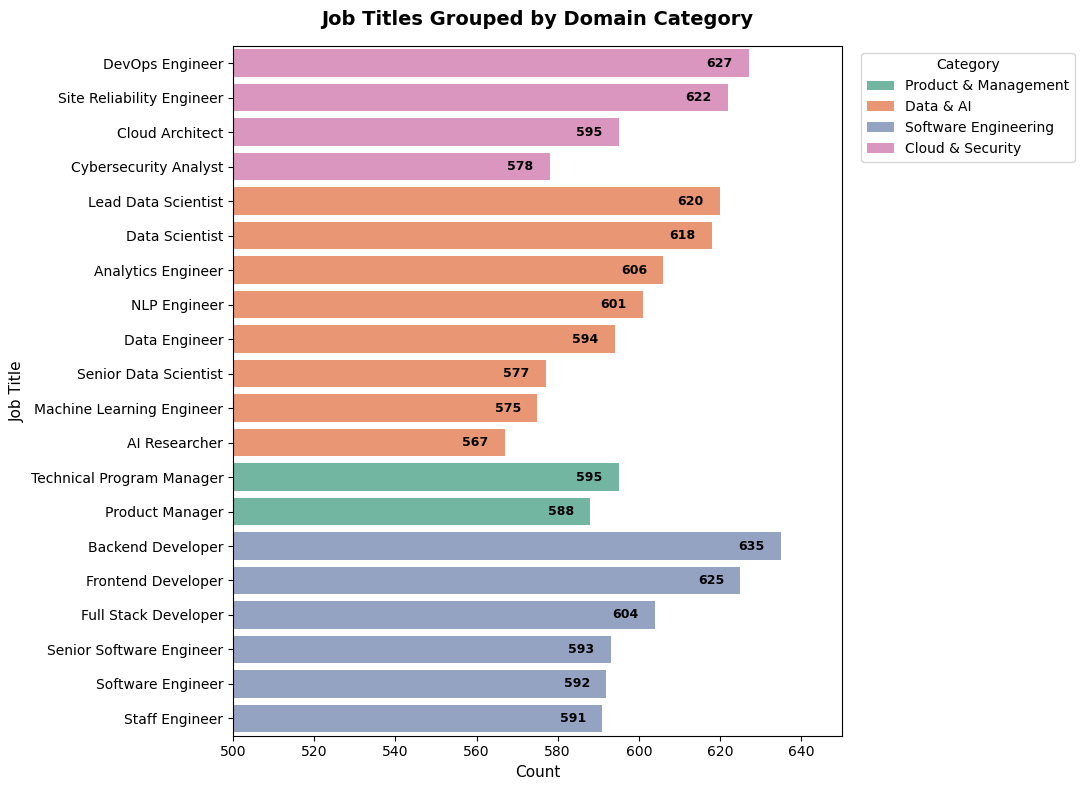

In [97]:
job_order = (
    data.groupby(["job_category", "job_title"])
    .size()
    .reset_index(name="count")
    .sort_values(by=["job_category", "count"], ascending=[True, False])[
        "job_title"
    ]
    .tolist()
)


plt.figure(figsize=(11, 8))
ax = sns.countplot(
    data=data,
    y="job_title",
    hue="job_category",
    order=job_order,
    dodge=False,
    palette="Set2",
)


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width - 4, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            color="black",
            fontsize=9,
            fontweight="bold",
        )


plt.title(
    "Job Titles Grouped by Domain Category",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Job Title", fontsize=11)
plt.xlim(500, 650)
plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

<div>

<div>

In [98]:
data['company_name'].value_counts()

company_name
NASA                               736
CyberDyne                          734
EduTech Global                     732
Initech                            729
GlobalSystems Inc                  720
Wayne Enterprises                  713
European Space Agency              710
HealthAI                           710
Department of Defense              704
Umbrella Corp                      700
Quantum Data                       698
AI Solutions LLC                   694
FinTech Innovations                690
Globex                             690
Federal Bureau of Investigation    687
Stark Industries                   678
TechNova                           678
Name: count, dtype: int64[pyarrow]

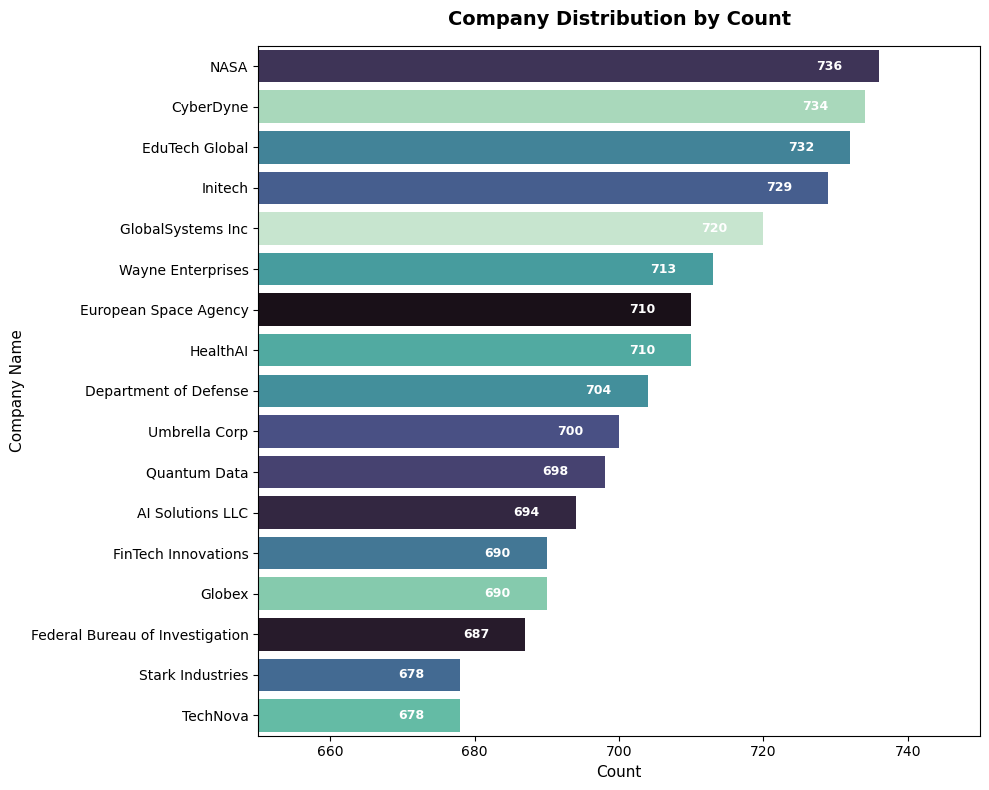

In [100]:

company_order = (
    data["company_name"].value_counts().index.tolist()
)  


plt.figure(figsize=(10, 8))
ax = sns.countplot(
    data=data,
    y="company_name",
    order=company_order,  
    palette="mako",
    hue="company_name",
)


for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f"{int(width)}",
            (width - 5, p.get_y() + p.get_height() / 2.0),
            ha="right",
            va="center",
            color="white",
            fontsize=9,
            fontweight="bold",
        )

plt.title(
    "Company Distribution by Count", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Count", fontsize=11)
plt.ylabel("Company Name", fontsize=11)
plt.xlim(650, 750)
plt.tight_layout()

plt.show()

<div>